In [2]:
##HOUSE PRICE PREDICTION
#Importation des librairies
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
#Télecharment du fichier
from google.colab import files
uploaded = files.upload()

Saving dataset_2.csv to dataset_2.csv


In [4]:
daset = pd.read_csv('dataset_2.csv')

In [5]:
daset

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0
...,...,...,...,...,...,...,...,...,...
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0
1122,NaN,6.0,2022,Delhi,Main Road,Unfurnished,Independent House,No,533436.0


In [6]:
## Affichage des 5 premières lignes
daset.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [7]:
##Vérification des valeurs nulles
daset.isnull().sum()

,0
Area_SqFt,33
Rooms,33
Build_Year,0
Location,0
Street_Type,0
Furnishing,33
Property_Type,0
Has_Pool,0
Price,0


In [8]:
##Suppression des colonnes contenants des valeurs manquantes
daset= daset.dropna()
daset.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [9]:
daset.isnull().sum()

,0
Area_SqFt,0
Rooms,0
Build_Year,0
Location,0
Street_Type,0
Furnishing,0
Property_Type,0
Has_Pool,0
Price,0


In [10]:
##Les statistiques
daset.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,1027.000000,1027.000000,1027.000000,1.027000e+03
mean,2238.749462,4.566699,2005.081792,6.098391e+05
std,744.704478,1.676631,11.791113,1.450773e+05
min,700.000000,2.000000,1985.000000,2.486400e+05
25%,1826.724874,3.000000,1995.000000,5.177645e+05
50%,2206.565229,5.000000,2005.000000,6.032640e+05
75%,2578.977535,6.000000,2015.000000,6.897460e+05
max,10267.124330,7.000000,2024.000000,2.071402e+06


In [11]:
##Changement des noms de variables
daset = daset.rename(columns={
    'Area_SqFt': 'Superficie',
    'Rooms': 'Chambres',
    'Build_Year': 'Annee_Construction',
    'Location': 'Localisation',
    'Street_Type': 'Type_Rue',
    'Furnishing': 'Meuble',
    'Property_Type': 'Type_Propriete',
    'Has_Pool': 'Piscine',
    'Price': 'Prix'})
daset.head()

,Superficie,Chambres,Annee_Construction,Localisation,Type_Rue,Meuble,Type_Propriete,Piscine,Prix
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [12]:
# Traduction des valeurs categorielles en francais
# Translation for 'Street_Type' (Type_Rue)
daset['Type_Rue'] = daset['Type_Rue'].replace({
    'Residential Lane': 'Voie Résidentielle',
    'Corner Plot': 'Terrain d\'angle',
    'Highway Facing': 'Face à l\'autoroute',
    'Main Road': 'Route Principale'
})

# Translation for 'Furnishing' (Meuble)
daset['Meuble'] = daset['Meuble'].replace({
    'Furnished': 'Meublé',
    'Unfurnished': 'Non Meublé',
    'Semi-Furnished': 'Semi-Meublé'
})

# Translation for 'Property_Type' (Type_Propriete)
daset['Type_Propriete'] = daset['Type_Propriete'].replace({
    'Apartment': 'Appartement',
    'Duplex': 'Duplex',
    'Villa': 'Villa',
    'Independent House': 'Maison Individuelle'
})

# Translation for 'Has_Pool' (Piscine)
daset['Piscine'] = daset['Piscine'].replace({
    'Yes': 'Oui',
    'No': 'Non'
})



In [13]:
# Vérification des valeurs uniques des colonnes traduites pour vous assurer de leur exactitude.
print("Unique values for Type_Rue:", daset['Type_Rue'].unique())
print("Unique values for Meuble:", daset['Meuble'].unique())
print("Unique values for Type_Propriete:", daset['Type_Propriete'].unique())
print("Unique values for Piscine:", daset['Piscine'].unique())

Unique values for Type_Rue: ['Voie Résidentielle' "Terrain d'angle" "Face à l'autoroute"
 'Route Principale' 'Gated Society']
Unique values for Meuble: ['Meublé' 'Non Meublé' 'Semi-Meublé']
Unique values for Type_Propriete: ['Appartement' 'Duplex' 'Villa' 'Maison Individuelle']
Unique values for Piscine: ['Non' 'Oui']


In [14]:
# Affichage du DataFrame avec les valeurs traduites.
daset.head()

,Superficie,Chambres,Annee_Construction,Localisation,Type_Rue,Meuble,Type_Propriete,Piscine,Prix
0,2473.192784,4.0,1992,Jaipur,Voie Résidentielle,Meublé,Appartement,Non,568486.0
1,2353.472711,4.0,2006,Indore,Terrain d'angle,Non Meublé,Appartement,Oui,577214.0
2,2212.222005,3.0,2012,Jaipur,Face à l'autoroute,Semi-Meublé,Duplex,Non,581300.0
3,2823.886596,6.0,1993,Lucknow,Route Principale,Non Meublé,Villa,Oui,794614.0
4,1869.648721,5.0,2012,Jaipur,Terrain d'angle,Semi-Meublé,Appartement,Non,493086.0


In [15]:
daset['Chambres'].value_counts()

,count
Chambres,
4.0,188
5.0,181
7.0,175
6.0,171
3.0,158
2.0,154


<Axes: xlabel='Meuble'>

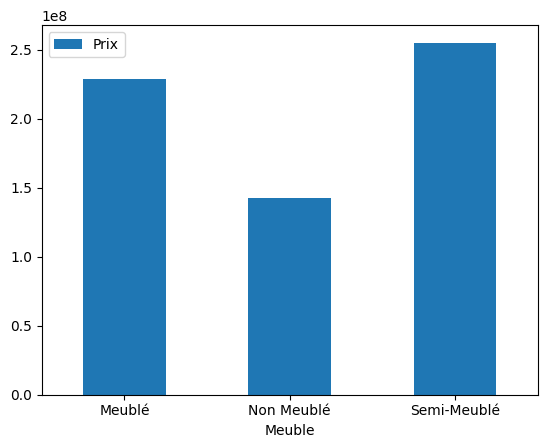

In [29]:
daset.groupby('Meuble')['Prix'].sum().plot(kind ='bar',rot = 0,legend =True)

<Axes: xlabel='Annee_Construction'>

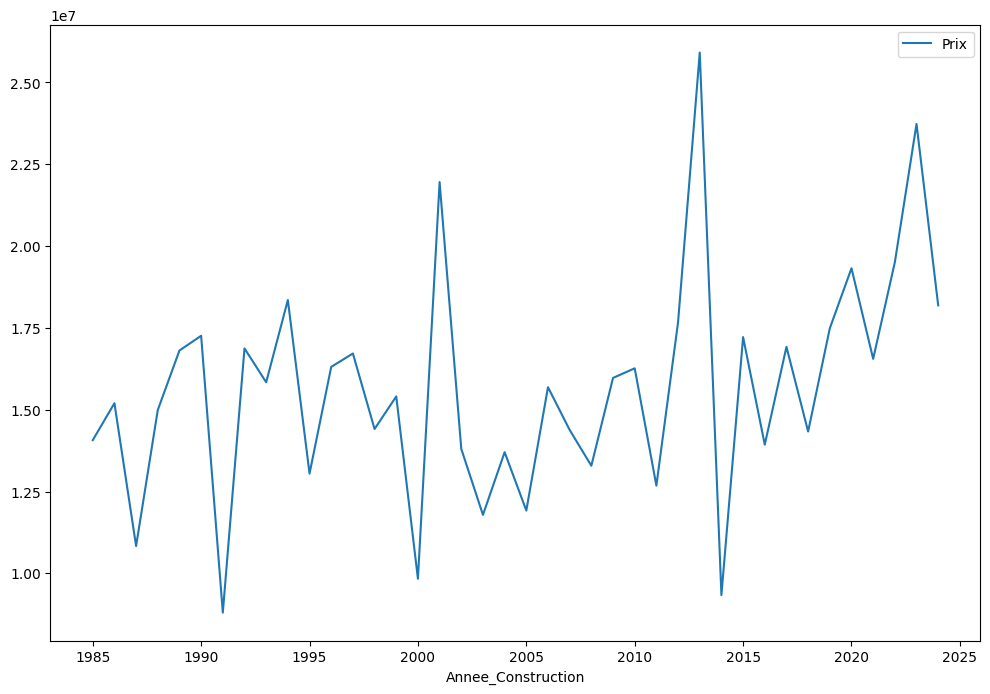

In [30]:
daset.groupby('Annee_Construction')['Prix'].sum().plot(kind ='line',figsize = (12,8), rot=0,legend =True)